# Credit Card Fraud Detection

Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Simple workflow: load the data, look at it, train a couple of models, check how well they catch fraud.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

## Load the data

In [2]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.isnull().sum().sum()  # check for missing values

np.int64(0)

## How imbalanced is it?

Fraud is a tiny fraction of all transactions, so accuracy alone won't tell us much.

In [5]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

Fraud cases are only 0.173% of all transactions


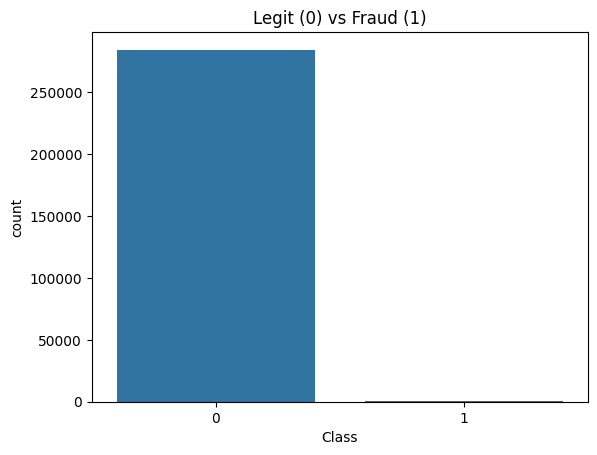

In [6]:
fraud_pct = df["Class"].mean() * 100
print(f"Fraud cases are only {fraud_pct:.3f}% of all transactions")

sns.countplot(x="Class", data=df)
plt.title("Legit (0) vs Fraud (1)")
plt.show()

## A quick look at transaction amounts

In [7]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


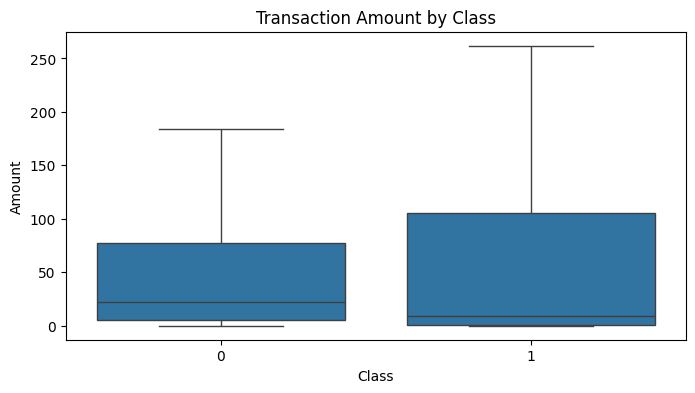

In [8]:
plt.figure(figsize=(8,4))
sns.boxplot(x="Class", y="Amount", data=df, showfliers=False)
plt.title("Transaction Amount by Class")
plt.show()

## Prepare the data

Scale `Amount` so it's on a similar range to the other (already-scaled) features, then split into train/test.

In [9]:
df["Amount"] = StandardScaler().fit_transform(df[["Amount"]])

X = df.drop(columns=["Class", "Time"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((213605, 29), (71202, 29))

## Model 1: Logistic Regression

In [10]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=["Legit", "Fraud"]))

              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     71079
       Fraud       0.06      0.89      0.11       123

    accuracy                           0.98     71202
   macro avg       0.53      0.93      0.55     71202
weighted avg       1.00      0.98      0.99     71202



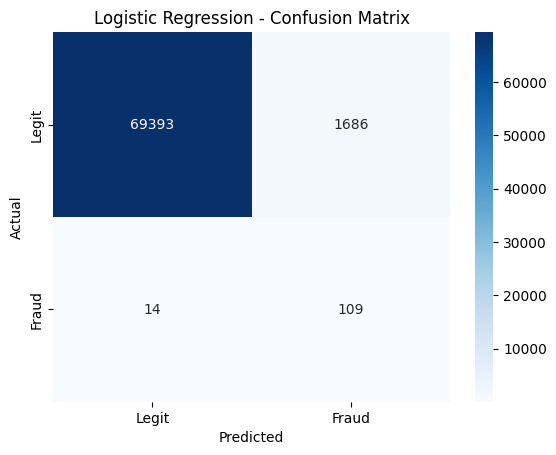

In [11]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## Model 2: Random Forest

In [12]:
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=["Legit", "Fraud"]))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     71079
       Fraud       0.97      0.72      0.83       123

    accuracy                           1.00     71202
   macro avg       0.98      0.86      0.91     71202
weighted avg       1.00      1.00      1.00     71202



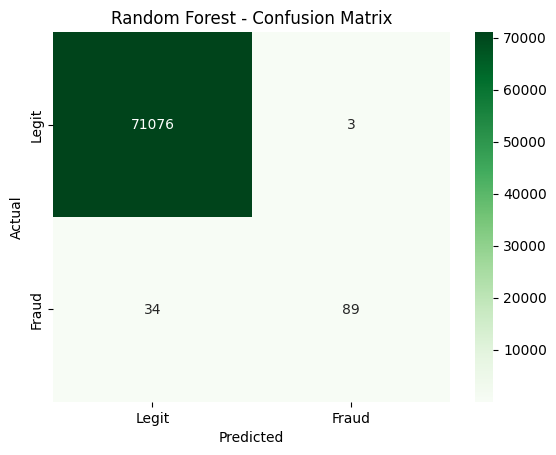

In [13]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

## Compare ROC curves

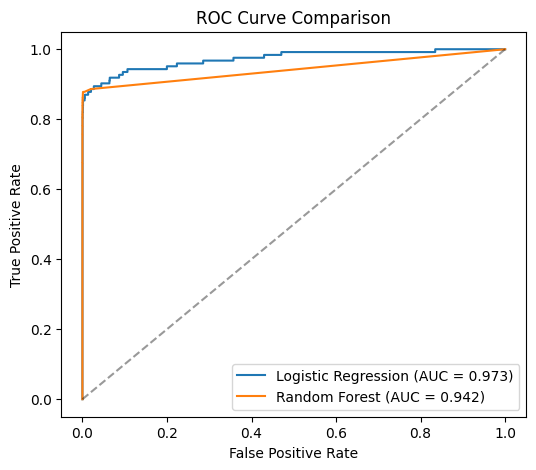

In [14]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})")
plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## What features matter most? (Random Forest)

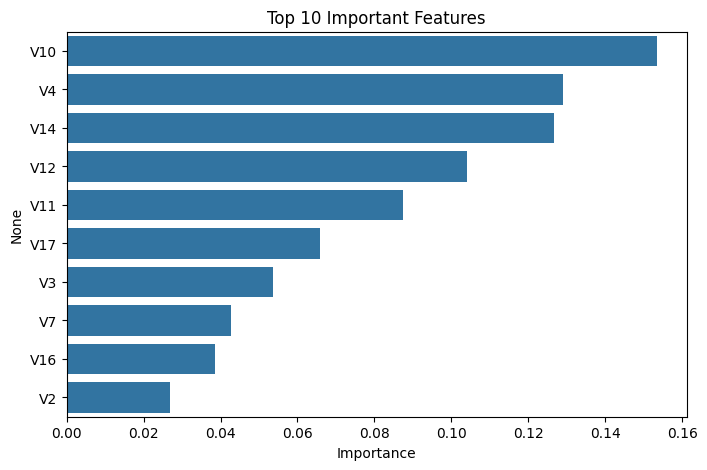

In [15]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

## Conclusion

Random Forest catches more fraud than Logistic Regression, at the cost of being less interpretable. Given how rare fraud is in this dataset, precision/recall on the fraud class matter a lot more than overall accuracy.

A simple Streamlit app (`app.py`) is included alongside this notebook to explore these same results interactively.